# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [13]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [14]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [15]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [16]:
df_median_household_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_people_below_poverty_level = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_over_25_completed_highschool = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_by_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_deaths_by_police = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [17]:
print(f"Shape of Median Household Income data: {df_median_household_income.shape}")
print(f"Shape of Percentage People Below Poverty Level data: {df_pct_people_below_poverty_level.shape}")
print(f"Shape of Percentage Over 25 Completed Highschool data: {df_pct_over_25_completed_highschool.shape}")
print(f"Shape of Share of Race by City data: {df_share_race_by_city.shape}")
print(f"Shape of Deaths caused by Police in US data: {df_deaths_by_police.shape}")

Shape of Median Household Income data: (29322, 3)
Shape of Percentage People Below Poverty Level data: (29329, 3)
Shape of Percentage Over 25 Completed Highschool data: (29329, 3)
Shape of Share of Race by City data: (29268, 7)
Shape of Deaths caused by Police in US data: (2535, 14)


In [18]:
print(f"Shape of Median Household Income data:\nRows: {df_median_household_income.shape[0]} Columns: {df_median_household_income.shape[1]}")
print(f"Shape of Percentage People Below Poverty Level data:\nRows: {df_pct_people_below_poverty_level.shape[0]} Columns: {df_pct_people_below_poverty_level.shape[1]}")
print(f"Shape of Percentage Over 25 Completed Highschool data:\nRows: {df_pct_over_25_completed_highschool.shape[0]} Columns: {df_pct_over_25_completed_highschool.shape[1]}")
print(f"Shape of Share of Race by City data:\nRows: {df_share_race_by_city.shape[0]} Columns: {df_share_race_by_city.shape[1]}")
print(f"Shape of Deaths caused by Police in US data:\nRows: {df_deaths_by_police.shape[0]} Columns: {df_deaths_by_police.shape[1]}")

Shape of Median Household Income data:
Rows: 29322 Columns: 3
Shape of Percentage People Below Poverty Level data:
Rows: 29329 Columns: 3
Shape of Percentage Over 25 Completed Highschool data:
Rows: 29329 Columns: 3
Shape of Share of Race by City data:
Rows: 29268 Columns: 7
Shape of Deaths caused by Police in US data:
Rows: 2535 Columns: 14


In [19]:
print(f"Shape of Median Household Income column names: {df_median_household_income.columns}")
print(f"Shape of Percentage People Below Poverty Level column names: {df_pct_people_below_poverty_level.columns}")
print(f"Shape of Percentage Over 25 Completed Highschool column names: {df_pct_over_25_completed_highschool.columns}")
print(f"Shape of Share of Race by City column names: {df_share_race_by_city.columns}")
print(f"Shape of Deaths caused by Police in US column names: {df_deaths_by_police.columns}")

Shape of Median Household Income column names: Index(['Geographic Area', 'City', 'Median Income'], dtype='str')
Shape of Percentage People Below Poverty Level column names: Index(['Geographic Area', 'City', 'poverty_rate'], dtype='str')
Shape of Percentage Over 25 Completed Highschool column names: Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='str')
Shape of Share of Race by City column names: Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='str')
Shape of Deaths caused by Police in US column names: Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='str')


In [20]:
print(f"Median Household Income NaN values:\n{df_median_household_income.isnull().sum()}")
print(f"\nPercentage People Below Poverty Level NaN values:\n{df_pct_people_below_poverty_level.isnull().sum()}")
print(f"\nPercentage Over 25 Completed Highschool NaN values:\n{df_pct_over_25_completed_highschool.isnull().sum()}")
print(f"\nShare of Race by City NaN values:\n{df_share_race_by_city.isnull().sum()}")
print(f"\nDeaths caused by Police in US NaN values:\n{df_deaths_by_police.isnull().sum()}")

Median Household Income NaN values:
Geographic Area     0
City                0
Median Income      51
dtype: int64

Percentage People Below Poverty Level NaN values:
Geographic Area    0
City               0
poverty_rate       0
dtype: int64

Percentage Over 25 Completed Highschool NaN values:
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64

Share of Race by City NaN values:
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64

Deaths caused by Police in US NaN values:
id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness 

In [21]:
print(df_median_household_income.duplicated().sum())
print(df_pct_people_below_poverty_level.duplicated().sum())
print(df_pct_over_25_completed_highschool.duplicated().sum())
print(df_share_race_by_city.duplicated().sum())
print(df_deaths_by_police.duplicated().sum())

0
0
0
0
0


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [22]:
datasets = [df_median_household_income, df_pct_people_below_poverty_level, df_pct_over_25_completed_highschool, df_share_race_by_city, df_deaths_by_police]

def swap_nans_with_zero():
    for data in datasets:
        for col in data.columns:
            if data[col].dtype == 'object' or hasattr(data[col], 'str'):
                data[col] = data[col].fillna('Unknown')
            else:
                data[col] = data[col].fillna(0)

swap_nans_with_zero()


In [23]:
print(f"Median Household Income NaN values:\n{df_median_household_income.isnull().sum()}")
print(f"\nPercentage People Below Poverty Level NaN values:\n{df_pct_people_below_poverty_level.isnull().sum()}")
print(f"\nPercentage Over 25 Completed Highschool NaN values:\n{df_pct_over_25_completed_highschool.isnull().sum()}")
print(f"\nShare of Race by City NaN values:\n{df_share_race_by_city.isnull().sum()}")
print(f"\nDeaths caused by Police in US NaN values:\n{df_deaths_by_police.isnull().sum()}")

Median Household Income NaN values:
Geographic Area    0
City               0
Median Income      0
dtype: int64

Percentage People Below Poverty Level NaN values:
Geographic Area    0
City               0
poverty_rate       0
dtype: int64

Percentage Over 25 Completed Highschool NaN values:
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64

Share of Race by City NaN values:
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64

Deaths caused by Police in US NaN values:
id                         0
name                       0
date                       0
manner_of_death            0
armed                      0
age                        0
gender                     0
race                       0
city                       0
state                      0
signs_of_mental_illness    0
threat_level      

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [27]:
state_abbreviations = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia'
}

# Fix poverty_rate dtype first
df_pct_people_below_poverty_level['poverty_rate'] = pd.to_numeric(
    df_pct_people_below_poverty_level['poverty_rate'], errors='coerce'
).fillna(0)

# Now groupby will work
df_poverty_by_state = df_pct_people_below_poverty_level.groupby('Geographic Area')['poverty_rate'].mean().reset_index()
df_poverty_by_state.columns = ['state', 'avg_poverty_rate']
df_poverty_by_state = df_poverty_by_state.sort_values('avg_poverty_rate', ascending=True)

df_poverty_by_state['state'] = df_poverty_by_state['state'].map(state_abbreviations)
df_poverty_by_state = df_poverty_by_state.dropna(subset=['state'])

print(df_poverty_by_state)


                   state  avg_poverty_rate
31            New Jersey              8.16
50               Wyoming              9.06
6            Connecticut              9.14
19         Massachusetts              9.55
20              Maryland             10.27
39          Rhode Island             10.37
34              New York             11.64
44                  Utah             11.72
28          North Dakota             12.13
12                  Iowa             12.23
33                Nevada             12.37
38          Pennsylvania             12.49
8               Delaware             12.56
30         New Hampshire             12.66
48             Wisconsin             12.86
29              Nebraska             12.92
5               Colorado             13.19
11                Hawaii             13.40
23             Minnesota             13.75
46               Vermont             13.79
14              Illinois             13.85
45              Virginia             14.59
16         

Index(['Geographic Area', 'City', 'poverty_rate'], dtype='str')


/tmp/ipykernel_68244/401637108.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


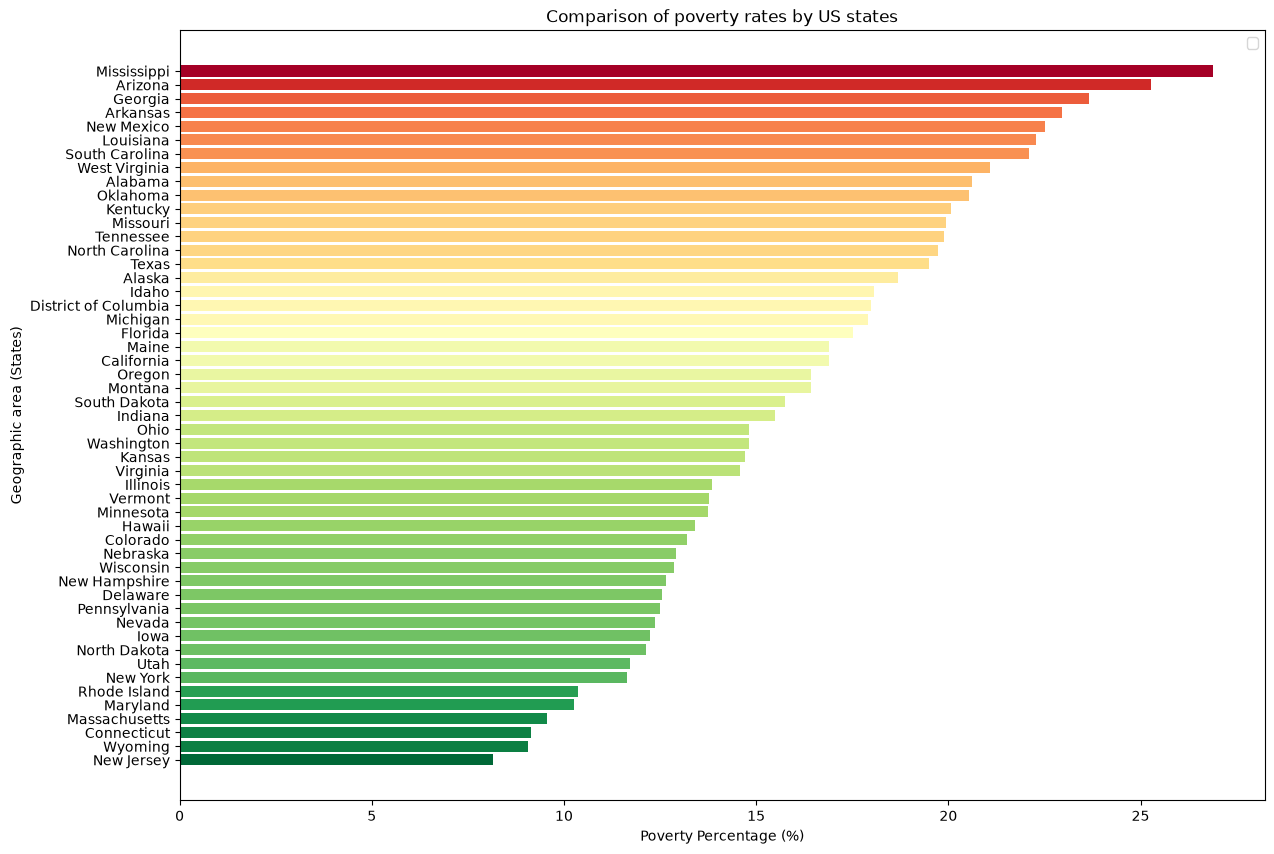

In [28]:
import matplotlib.colors as mcolors

print(df_pct_people_below_poverty_level.columns)

norm = mcolors.Normalize(vmin=df_poverty_by_state['avg_poverty_rate'].min(), vmax=df_poverty_by_state['avg_poverty_rate'].max())
colors = plt.cm.RdYlGn_r(norm(df_poverty_by_state['avg_poverty_rate']))

# bar chart
plt.figure(figsize=[14, 10])
plt.barh(df_poverty_by_state['state'], df_poverty_by_state['avg_poverty_rate'], color=colors)
plt.legend()
plt.xlabel('Poverty Percentage (%)')
plt.ylabel('Geographic area (States)')
plt.title('Comparison of poverty rates by US states')
plt.show()

In [29]:
import plotly.io as pio
print(pio.renderers)

Renderers configuration
-----------------------
    Default renderer: 'vscode'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [30]:
import plotly.express as px

# Group by state for choropleth
df_poverty_map = df_pct_people_below_poverty_level.groupby('Geographic Area')['poverty_rate'].mean().reset_index()
df_poverty_map.columns = ['state', 'avg_poverty_rate']

fig = px.choropleth(
    df_poverty_map,
    locations='state',
    locationmode='USA-states',
    color='avg_poverty_rate',
    scope='usa',
    color_continuous_scale='RdYlGn_r',
    title='Average Poverty Rate by US State',
    labels={'avg_poverty_rate': 'Avg Poverty Rate (%)'}
)

fig.update_layout(
    geo=dict(showlakes=True, lakecolor='LightBlue'),
    title_x=0.5
)

fig.show()

In [36]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'browser'

# Load free US cities dataset with lat/lon
us_cities_url = "https://raw.githubusercontent.com/kelvins/US-Cities-Database/main/csv/us_cities.csv"
df_us_cities = pd.read_csv(us_cities_url)
print(df_us_cities.columns)
print(df_us_cities.head())
print(df_us_cities.shape)

Index(['ID', 'STATE_CODE', 'STATE_NAME', 'CITY', 'COUNTY', 'LATITUDE',
       'LONGITUDE'],
      dtype='str')
   ID STATE_CODE STATE_NAME      CITY          COUNTY  LATITUDE  LONGITUDE
0   1         AK     Alaska      Adak  Aleutians West     56.00    -161.21
1   2         AK     Alaska  Akiachak          Bethel     60.89    -161.39
2   3         AK     Alaska     Akiak          Bethel     60.89    -161.20
3   4         AK     Alaska    Akutan  Aleutians East     54.14    -165.79
4   5         AK     Alaska  Alakanuk        Kusilvak     62.75    -164.60
(29880, 7)


In [37]:
# Check what the city names look like in each dataset
print("Poverty dataset sample:")
print(df_pct_people_below_poverty_level[['City', 'Geographic Area']].head(10))

print("\nUS Cities dataset sample:")
print(df_us_cities[['CITY', 'STATE_CODE']].head(10))

# Check for mismatches - cities in poverty data not found in us_cities
poverty_cities = set(zip(df_pct_people_below_poverty_level['City'], df_pct_people_below_poverty_level['Geographic Area']))
us_cities = set(zip(df_us_cities['CITY'], df_us_cities['STATE_CODE']))

unmatched = poverty_cities - us_cities
print(f"\nUnmatched cities: {len(unmatched)}")
print("\nSample of unmatched:")
for city, state in list(unmatched)[:20]:
    print(f"  '{city}', '{state}'")

Poverty dataset sample:
                  City Geographic Area
0           Abanda Cdp              AL
1       Abbeville City              AL
2      Adamsville City              AL
3         Addison Town              AL
4           Akron Town              AL
5       Alabaster City              AL
6     Albertville City              AL
7  Alexander City City              AL
8       Alexandria Cdp              AL
9      Aliceville City              AL

US Cities dataset sample:
             CITY STATE_CODE
0            Adak         AK
1        Akiachak         AK
2           Akiak         AK
3          Akutan         AK
4        Alakanuk         AK
5       Aleknagik         AK
6       Allakaket         AK
7          Ambler         AK
8  Anaktuvuk Pass         AK
9    Anchor Point         AK

Unmatched cities: 29318

Sample of unmatched:
  'Little Valley Village', 'NY'
  'Browerville City', 'MN'
  'Platte Woods City', 'MO'
  'Leota Cdp', 'MN'
  'Epps Village', 'LA'
  'Fort Campbell North C

In [40]:
# Remove suffixes from city names
suffixes = [' City', ' Town', ' Village', ' Cdp', ' Borough', ' Township', 
            ' Census Designated Place', ' Municipality', ' Plantation']

def remove_suffix(name):
    for suffix in suffixes:
        if name.endswith(suffix):
            return name[:-len(suffix)].strip()
    return name

df_pct_people_below_poverty_level['City_clean'] = df_pct_people_below_poverty_level['City'].apply(remove_suffix)

print("Before:", df_pct_people_below_poverty_level['City'].head(5).tolist())
print("After: ", df_pct_people_below_poverty_level['City_clean'].head(5).tolist())

Before: ['Abanda Cdp', 'Abbeville City', 'Adamsville City', 'Addison Town', 'Akron Town']
After:  ['Abanda', 'Abbeville', 'Adamsville', 'Addison', 'Akron']


In [55]:
df_city_poverty = df_pct_people_below_poverty_level.merge(
    df_us_cities[['CITY', 'STATE_CODE', 'LATITUDE', 'LONGITUDE']],
    left_on=['City_clean', 'Geographic Area'],
    right_on=['CITY', 'STATE_CODE'],
    how='inner'
)

print(df_city_poverty.head())

df_city_poverty = df_city_poverty.sort_values('poverty_rate', ascending=True).reset_index(drop=True)

print(df_city_poverty.head())

print(f"Matched {len(df_city_poverty)} cities")

df_city_poverty_filtered = df_city_poverty[df_city_poverty['poverty_rate'] > 10]
print(f"Cities with poverty rate above 10%: {len(df_city_poverty_filtered)}")

  Geographic Area             City  poverty_rate  City_clean        CITY  \
0              AL   Abbeville City         29.10   Abbeville   Abbeville   
1              AL  Adamsville City         25.50  Adamsville  Adamsville   
2              AL     Addison Town         30.70     Addison     Addison   
3              AL       Akron Town         42.00       Akron       Akron   
4              AL   Alabaster City         11.20   Alabaster   Alabaster   

  STATE_CODE  LATITUDE  LONGITUDE  
0         AL     31.58     -85.28  
1         AL     33.59     -86.96  
2         AL     34.21     -87.19  
3         AL     32.87     -87.71  
4         AL     33.24     -86.81  
  Geographic Area             City  poverty_rate   City_clean         CITY  \
0              NM   Loco Hills Cdp          0.00   Loco Hills   Loco Hills   
1              MT  Silver Gate Cdp          0.00  Silver Gate  Silver Gate   
2              MT     Stockett Cdp          0.00     Stockett     Stockett   
3              

In [56]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'browser'

fig = px.scatter_mapbox(
    df_city_poverty_filtered,
    lat='LATITUDE',
    lon='LONGITUDE',
    color='poverty_rate',
    size='poverty_rate',
    hover_name='City',
    hover_data={'poverty_rate': True, 'Geographic Area': True},
    color_continuous_scale='RdYlGn_r',
    size_max=20,
    zoom=3,
    title='Poverty Rate by City across the US',
    labels={'poverty_rate': 'Poverty Rate (%)'}
)

fig.update_layout(
    mapbox_style='open-street-map',  # free, no API key needed
    title_x=0.5,
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

/tmp/ipykernel_68244/685834293.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [62]:
state_abbreviations = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia'
}

In [63]:
print(df_pct_over_25_completed_highschool.columns)

df_pct_over_25_completed_highschool['percent_completed_hs'] = pd.to_numeric(
    df_pct_over_25_completed_highschool['percent_completed_hs'], errors='coerce'
).fillna(0)

df_pct_over_25_completed_highschool_by_states = (
    df_pct_over_25_completed_highschool
    .groupby('Geographic Area')['percent_completed_hs']
    .mean()
    .reset_index()
    .sort_values('percent_completed_hs', ascending=True)
)

df_pct_over_25_completed_highschool_by_states['state'] = df_pct_over_25_completed_highschool_by_states['Geographic Area'].map(state_abbreviations)


print(df_pct_over_25_completed_highschool_by_states.head(5))

Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='str')
   Geographic Area  percent_completed_hs        state
43              TX                 74.09        Texas
25              MS                 78.47  Mississippi
10              GA                 78.63      Georgia
32              NM                 78.97   New Mexico
18              LA                 79.12    Louisiana


In [66]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'browser'

fig = px.choropleth(
    df_pct_over_25_completed_highschool_by_states,
    locations='Geographic Area',  # use abbreviations, not full names
    locationmode='USA-states',
    color='percent_completed_hs',
    scope='usa',
    color_continuous_scale='RdYlGn',  # string, not matplotlib colors
    title='Average High School Graduation Rate by US State',
    labels={'percent_completed_hs': 'Avg HS Graduation Rate (%)'}
)

fig.update_layout(
    geo=dict(showlakes=True, lakecolor='LightBlue'),
    title_x=0.5
)

fig.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [70]:
df_poverty_by_state.head(5)

compare_hs_graduation_and_poverty = df_poverty_by_state.merge(
    df_pct_over_25_completed_highschool_by_states,
    on = 'state',
    how = 'inner'
)

compare_hs_graduation_and_poverty.head(5)

,state,avg_poverty_rate,Geographic Area,percent_completed_hs
0,New Jersey,8.16,NJ,90.52
1,Wyoming,9.06,WY,83.97
2,Connecticut,9.14,CT,91.59
3,Massachusetts,9.55,MA,92.03
4,Maryland,10.27,MD,88.08


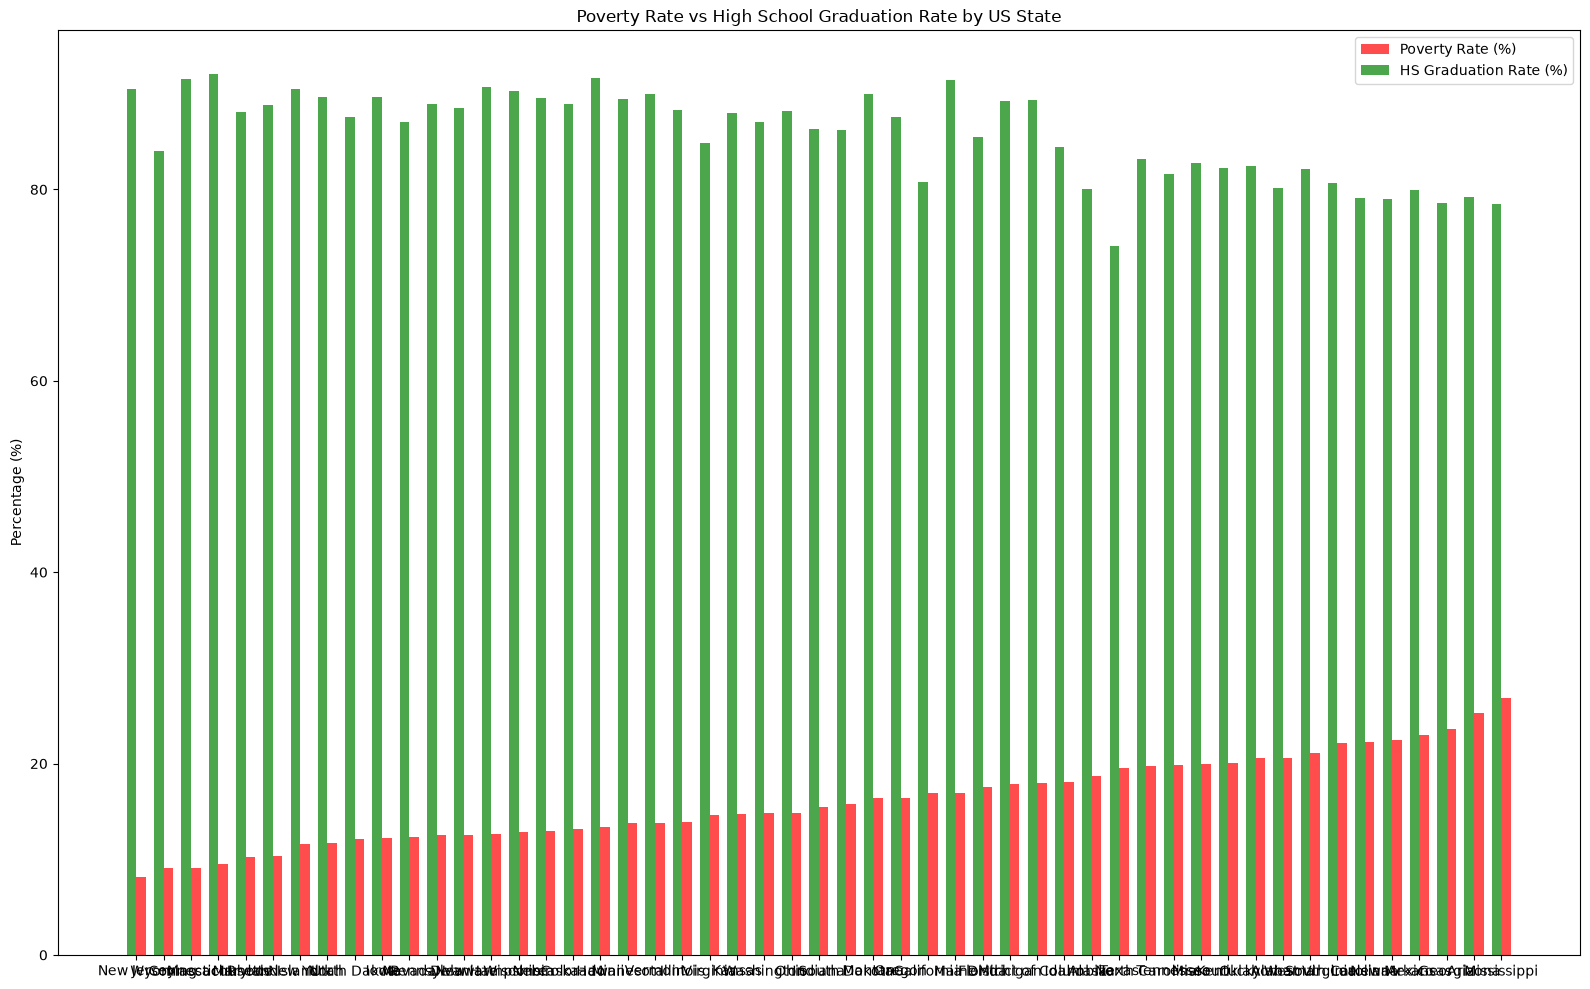

In [ ]:
sorted_compare_hs_graduation_and_poverty = compare_hs_graduation_and_poverty.sort_values('avg_poverty_rate', ascending=True)
x = np.arange(len(sorted_compare_hs_graduation_and_poverty))  # label positions
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(16, 10))

bars1 = ax.bar(x + width/2, sorted_compare_hs_graduation_and_poverty['avg_poverty_rate'], width, label='Poverty Rate (%)', color='red', alpha=0.7)
bars2 = ax.bar(x - width/2, sorted_compare_hs_graduation_and_poverty['percent_completed_hs'], width, label='HS Graduation Rate (%)', color='green', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(
    sorted_compare_hs_graduation_and_poverty['state'] if 'state' in sorted_compare_hs_graduation_and_poverty.columns else sorted_compare_hs_graduation_and_poverty['Geographic Area'],
    rotation=45,
    ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Poverty Rate vs High School Graduation Rate by US State')
ax.legend()

plt.tight_layout()
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).